In [1]:
import pandas as pd
import numpy as np
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras.utils import Sequence
import tensorflow as tf
from tqdm import tqdm
import warnings
import os
import pickle
import hashlib
from concurrent.futures import ThreadPoolExecutor, as_completed
import time

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

## Configuration

In [ ]:
BATCH_SIZE = 32
TARGET_SIZE = (224, 224)
MAX_IMAGES = None  # Set to None for all images, or a number for testing
CACHE_DIR = '/kaggle/working/image_cache'
FEATURES_CACHE = '/kaggle/working/image_features.npy'
PCA_CACHE = '/kaggle/working/pca_features.npy'

os.makedirs(CACHE_DIR, exist_ok=True)

## Load Product Data and Image URLs

In [2]:
# Load your products DataFrame (example)
products_df = pd.read_csv('/kaggle/input/datasets/tahmidakter/products-cleaned/cleaned_products_20260831_163948.csv')

# Keep only rows with valid image URLs
products_df = products_df[products_df['image_url'].notna() & (products_df['image_url'] != '') & (products_df['image_url'] != 'N/A')]

print(f"Number of products with images: {len(products_df)}")

Number of products with images: 620


## Image downloading and preprocessing

In [7]:
def download_and_preprocess(url, target_size=(224,224)):
    """Download image from URL and preprocess for VGG16."""
    try:
        response = requests.get(url, timeout=10)
        img = Image.open(BytesIO(response.content)).convert('RGB')
        img = img.resize(target_size)
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        return preprocess_input(img_array)
    except Exception as e:
        return None

# Limit to first 200 images for demonstration
N_IMAGES = 620
subset = products_df.head(N_IMAGES).copy()

# Preprocess all images and store in a list
features = []
valid_indices = []
print("Downloading and preprocessing images...")
for idx, row in subset.iterrows():
    img_preprocessed = download_and_preprocess(row['image_url'])
    if img_preprocessed is not None:
        features.append(img_preprocessed)
        valid_indices.append(idx)

features = np.vstack(features)
print(f"Successfully processed {len(features)} images.")

Successfully processed 620 images.


Extract Features using VGG16

In [8]:
# Load VGG16 without top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Use the output of the last pooling layer as feature
model = Model(inputs=base_model.input, outputs=base_model.get_layer('block5_pool').output)

# Extract features for all images
print("Extracting features...")
image_features = model.predict(features, verbose=1)

# Flatten the features
n_samples = image_features.shape[0]
image_features_flat = image_features.reshape(n_samples, -1)
print(f"Feature vector shape: {image_features_flat.shape}")

Extracting features...
20/20 ━━━━━━━━━━━━━━━━━━━━ 183s 9s/step
Feature vector shape: (620, 25088)


In [9]:
pca = PCA(n_components=0.95, random_state=42)
features_pca = pca.fit_transform(image_features_flat)
print(f"Reduced feature dimension: {features_pca.shape[1]}")

Reduced feature dimension: 452


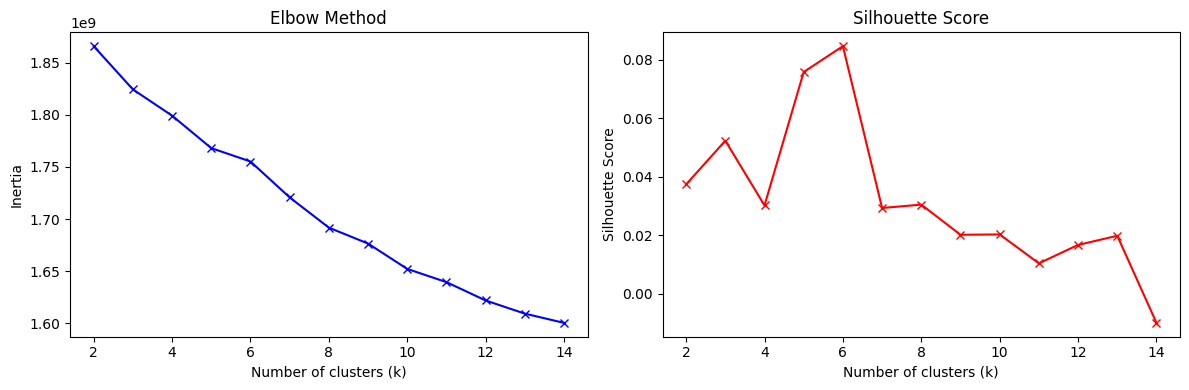

In [10]:
inertias = []
silhouette_scores = []
K_range = range(2, 15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_pca)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(features_pca, kmeans.labels_))

# Plot elbow curve
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K_range, inertias, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1,2,2)
plt.plot(K_range, silhouette_scores, 'rx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.tight_layout()
plt.show()

In [12]:
OPTIMAL_K = 6
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features_pca)

# Add cluster labels to the subset
subset['cluster'] = np.nan
subset.loc[valid_indices, 'cluster'] = cluster_labels

## Apply K-means cluster

In [13]:
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features_pca)

# Add cluster labels to the subset
subset['cluster'] = np.nan
subset.loc[valid_indices, 'cluster'] = cluster_labels

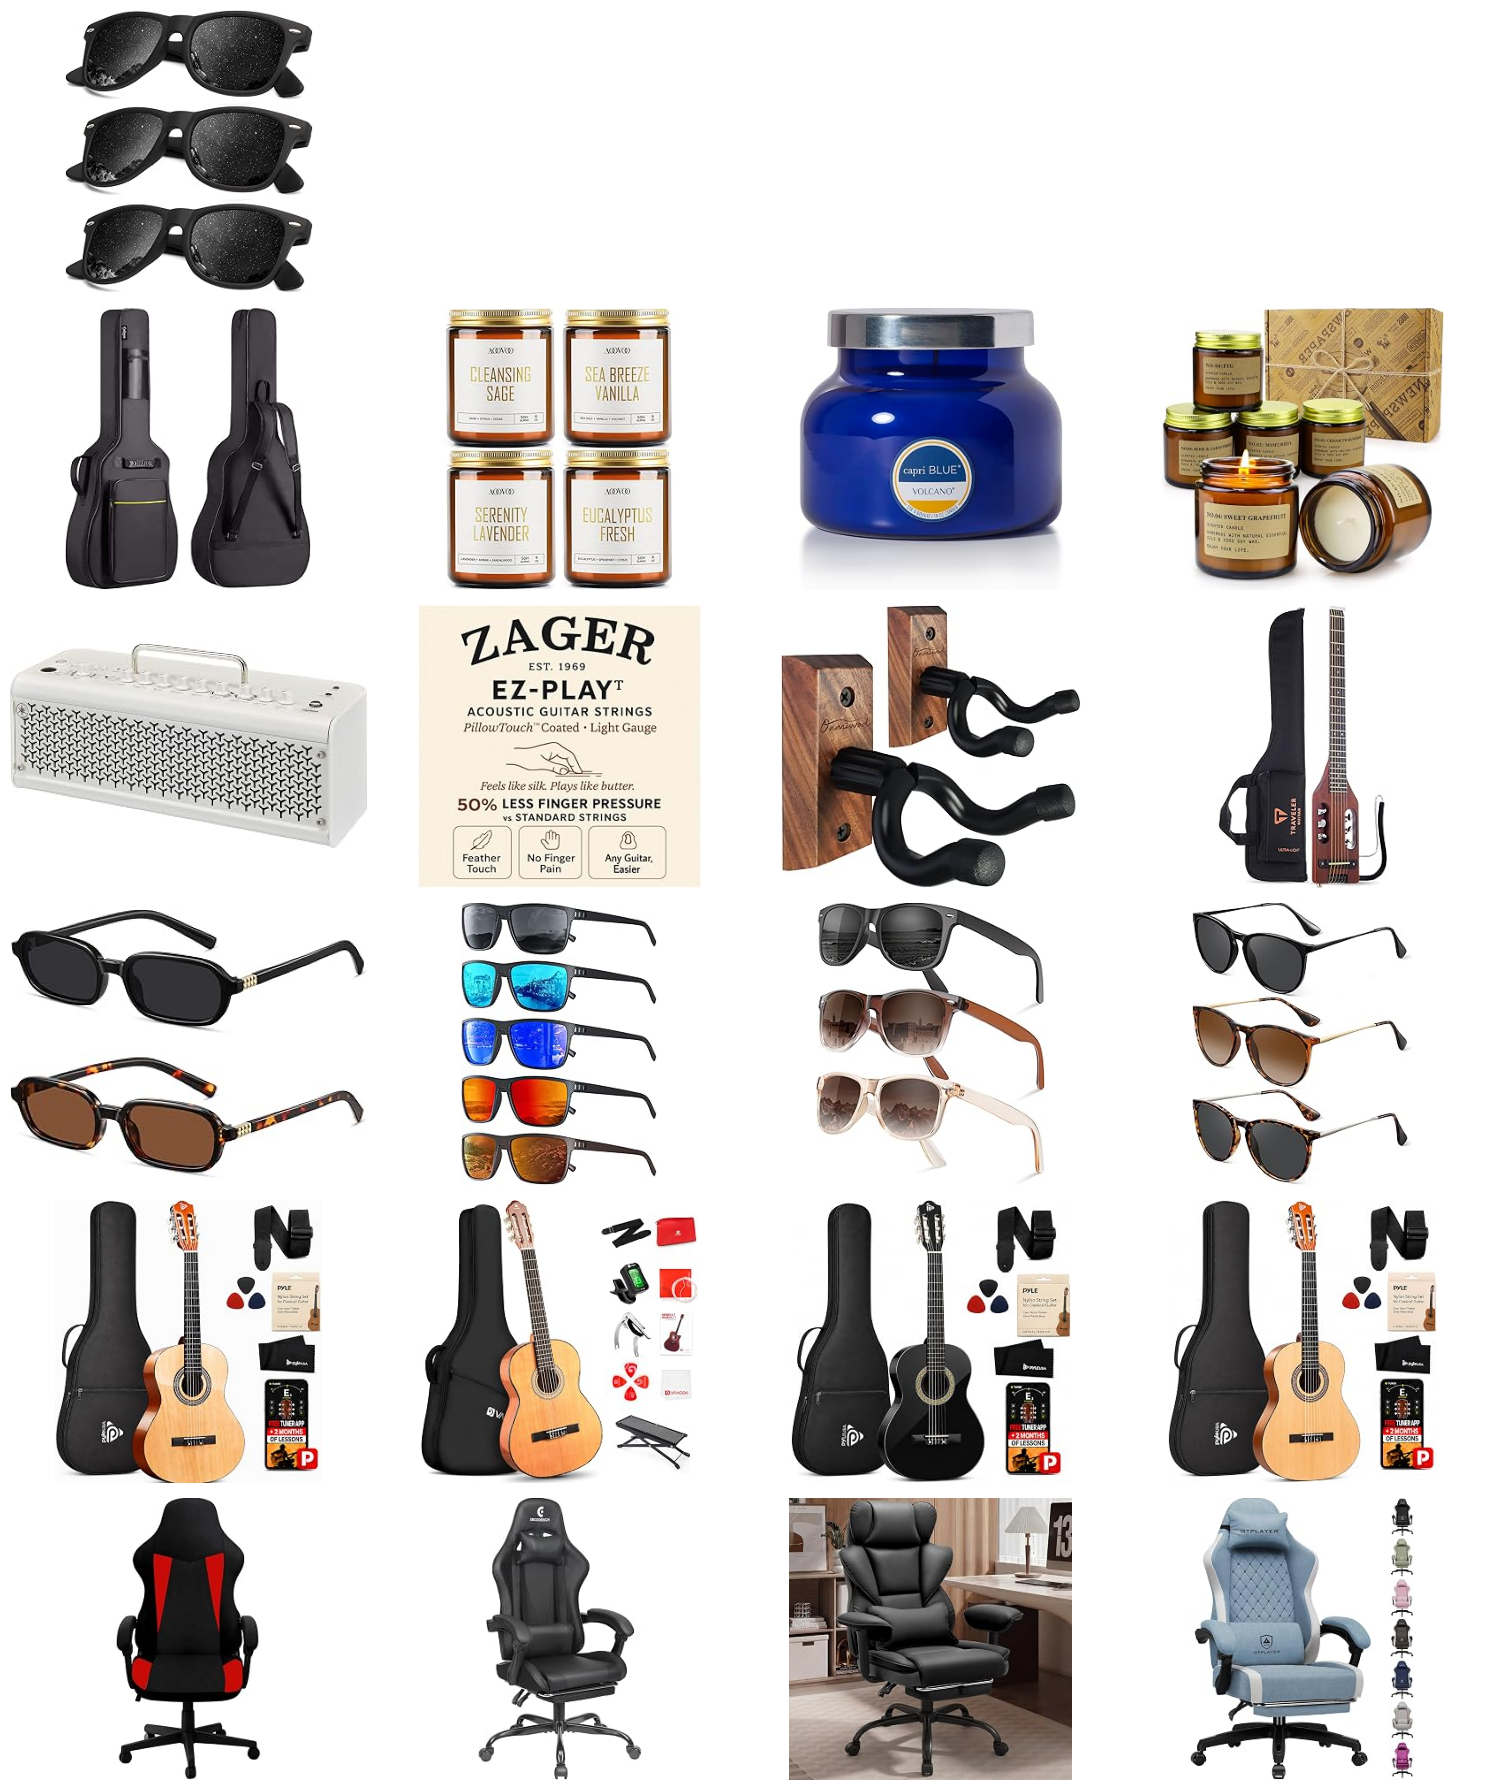

In [14]:
n_cols = 4  # number of sample images to show per cluster
fig, axes = plt.subplots(OPTIMAL_K, n_cols, figsize=(15, OPTIMAL_K*3))

for cluster_id in range(OPTIMAL_K):
    cluster_products = subset[subset['cluster'] == cluster_id]
    cluster_size = len(cluster_products)
    
    # Get sample image URLs (first 4)
    sample_urls = cluster_products['image_url'].head(n_cols).tolist()
    
    for col in range(n_cols):
        ax = axes[cluster_id, col]
        if col < len(sample_urls):
            try:
                response = requests.get(sample_urls[col], timeout=5)
                img = Image.open(BytesIO(response.content))
                ax.imshow(img)
            except:
                ax.text(0.5, 0.5, 'No image', ha='center', va='center')
        ax.axis('off')
    
    axes[cluster_id, 0].set_ylabel(f'Cluster {cluster_id}\nSize: {cluster_size}', fontsize=10)

plt.tight_layout()
plt.show()

In [15]:
cluster_counts = subset.groupby('cluster').size().reset_index(name='count')
print(cluster_counts)

   cluster  count
0      0.0      1
1      1.0    155
2      2.0    399
3      3.0     11
4      4.0     26
5      5.0     28
